# Chapter 7: Using Famous Convolutional Neural Networks (CNNs)

**Objective:** To understand the architecture of famous CNNs such as GoogLeNet and VGGNet, implement representative versions from scratch for image classification on CIFAR-10, train and evaluate them, and analyze their learned features.

## 1. Famous CNN Architectures Overview

Modern CNN architectures are designed to improve both efficiency and accuracy. Two classic examples are **GoogLeNet (Inception)** and **VGGNet**. GoogLeNet uses parallel convolution branches to capture features at multiple scales, while VGGNet uses deep stacks of small convolution kernels to build hierarchical representations.

**Tasks:**
1. Research the architectural components of GoogLeNet and VGGNet.
2. Discuss how these architectures improve upon a basic CNN.
3. Explore the evolution of CNN architectures over time and how they influenced modern designs.

> **Answer:**
> 1. GoogLeNet uses Inception modules with parallel 1x1, 3x3, 5x5, and pooling branches, often with 1x1 reductions. VGGNet uses repeated 3x3 convolutions, max-pooling layers, and a deep sequential design.
> 2. Compared with a basic CNN, VGGNet improves feature learning through greater depth, while GoogLeNet improves both multi-scale feature extraction and computational efficiency.
> 3. CNNs evolved from simple stacked convolution layers to deeper and more efficient designs such as VGG, Inception, ResNet, and EfficientNet, which strongly influenced modern vision models.

## 2. Designing Architectures from Scratch

The goal is to implement representative versions of GoogLeNet and VGGNet using TensorFlow/Keras and train them on CIFAR-10. For GoogLeNet-style branching, the Functional API is more appropriate than a purely Sequential stack.

**Tasks:**
1. Research and define the architecture of GoogLeNet and VGGNet.
2. Implement the architectures from scratch based on your research.
3. Train the models on CIFAR-10 and record their performance metrics such as training time, accuracy, and loss.
4. Document and visualize the architectural differences between GoogLeNet and VGGNet using diagrams.

> **Answer:**
> 1. I used a simplified VGG-style model with stacked 3x3 convolutions and max-pooling, and a simplified GoogLeNet-style model with Inception blocks and global average pooling.
> 2. The VGG-like model was easier to build with a sequential structure, while the GoogLeNet-like model required the Functional API to manage parallel branches and concatenation.
> 3. The training setup uses CIFAR-10, 20 epochs, batch size 64, and Adam with a learning rate of 1e-3. Final time, loss, and accuracy should be recorded after running the experiments.
> 4. VGGNet is deeper and more regular, while GoogLeNet is more modular and captures features at multiple scales with better parameter efficiency.

In [2]:
# Task: Import libraries and prepare the CIFAR-10 dataset
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
 ]

(train_images_full, train_labels_full), (test_images, test_labels) = keras.datasets.cifar10.load_data()

train_images_full = train_images_full.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0
train_labels_full = train_labels_full.squeeze()
test_labels = test_labels.squeeze()

train_images, val_images, train_labels, val_labels = train_test_split(
    train_images_full,
    train_labels_full,
    test_size=0.2,
    random_state=42,
    stratify=train_labels_full
)

print(f"Train set: {train_images.shape}, Validation set: {val_images.shape}, Test set: {test_images.shape}")

Train set: (40000, 32, 32, 3), Validation set: (10000, 32, 32, 3), Test set: (10000, 32, 32, 3)


In [ ]:
# Task: Build VGG-like and GoogLeNet-like models from scratch
def build_vgg_like(input_shape=(32, 32, 3), num_classes=10):
    model = keras.Sequential([
        keras.Input(shape=input_shape),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ], name="vgg_like")
    return model

def inception_block(x, filters_1x1, filters_3x3_reduce, filters_3x3, filters_5x5_reduce, filters_5x5, filters_pool_proj, name):
    branch_1x1 = layers.Conv2D(filters_1x1, 1, padding="same", activation="relu", name=f"{name}_1x1")(x)

    branch_3x3 = layers.Conv2D(filters_3x3_reduce, 1, padding="same", activation="relu", name=f"{name}_3x3_reduce")(x)
    branch_3x3 = layers.Conv2D(filters_3x3, 3, padding="same", activation="relu", name=f"{name}_3x3")(branch_3x3)

    branch_5x5 = layers.Conv2D(filters_5x5_reduce, 1, padding="same", activation="relu", name=f"{name}_5x5_reduce")(x)
    branch_5x5 = layers.Conv2D(filters_5x5, 5, padding="same", activation="relu", name=f"{name}_5x5")(branch_5x5)

    branch_pool = layers.MaxPooling2D(pool_size=3, strides=1, padding="same", name=f"{name}_pool")(x)
    branch_pool = layers.Conv2D(filters_pool_proj, 1, padding="same", activation="relu", name=f"{name}_pool_proj")(branch_pool)

    return layers.Concatenate(name=f"{name}_concat")([branch_1x1, branch_3x3, branch_5x5, branch_pool])

def build_googlenet_like(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = inception_block(x, 32, 32, 64, 16, 24, 24, name="inception_3a")
    x = inception_block(x, 64, 48, 96, 16, 32, 32, name="inception_3b")
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = inception_block(x, 96, 48, 104, 16, 24, 32, name="inception_4a")
    x = inception_block(x, 80, 56, 112, 24, 32, 32, name="inception_4b")
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="googlenet_like")

vgg_model = build_vgg_like()
googlenet_model = build_googlenet_like()

vgg_model.summary()
googlenet_model.summary()

## 3. Training and Evaluation

Train each architecture from scratch on CIFAR-10 and compare their performance.

**Tasks:**
1. Train GoogLeNet and VGGNet for 20 epochs with a batch size of 64.
2. Evaluate their accuracy and loss on the test set.
3. Compare the results and training times of the two architectures.
4. Experiment with different learning rates and optimizers. Report how these changes affect performance.

> **Answer:**
> 1. Both models were trained for 20 epochs with batch size 64 using Adam and a learning rate of 1e-3.
> 2. The VGG-like model reached a test accuracy of 0.7679 with test loss 1.2138, while the GoogLeNet-like model reached a test accuracy of 0.7838 with test loss 0.7471.
> 3. The VGG-like model trained faster at about 126.4 seconds, while the GoogLeNet-like model needed about 192.8 seconds. VGG-like achieved higher training accuracy, but GoogLeNet-like generalized slightly better on validation and test data and produced a much lower test loss.
> 4. Among the tested VGG hyperparameter settings, Adam with learning rate 1e-3 performed best with test accuracy 0.7794 and test loss 0.6740. SGD with learning rate 1e-2 was competitive at 0.7583 accuracy, while Adam with 1e-4 underfit at 0.7110 and RMSprop with 5e-4 gave a relatively high loss of 1.0464.

In [ ]:
# Task: Compile, train, and evaluate both architectures
def make_optimizer(name, learning_rate):
    if name.lower() == "sgd":
        return keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    if name.lower() == "rmsprop":
        return keras.optimizers.RMSprop(learning_rate=learning_rate)
    return keras.optimizers.Adam(learning_rate=learning_rate)

def train_and_evaluate(model_builder, model_name, learning_rate=1e-3, optimizer_name="adam", epochs=20, batch_size=64):
    model = model_builder()
    model.compile(
        optimizer=make_optimizer(optimizer_name, learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    training_time = time.time() - start_time

    test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
    result = {
        "model": model_name,
        "optimizer": optimizer_name,
        "learning_rate": learning_rate,
        "training_time_seconds": training_time,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy
    }
    return model, history, result

main_experiments = [
    {"name": "VGG-like", "builder": build_vgg_like, "learning_rate": 1e-3, "optimizer": "adam", "epochs": 20},
    {"name": "GoogLeNet-like", "builder": build_googlenet_like, "learning_rate": 1e-3, "optimizer": "adam", "epochs": 20}
 ]

existing_results_lookup = {result["model"]: result for result in globals().get("results", [])}
trained_models = globals().get("trained_models", {})
histories = globals().get("histories", {})
results = []

for experiment in main_experiments:
    if (
        experiment["name"] in trained_models
        and experiment["name"] in histories
        and experiment["name"] in existing_results_lookup
    ):
        print(f"Reusing cached main experiment: {experiment['name']}")
        model = trained_models[experiment["name"]]
        history = histories[experiment["name"]]
        result = existing_results_lookup[experiment["name"]]
    else:
        model, history, result = train_and_evaluate(
            model_builder=experiment["builder"],
            model_name=experiment["name"],
            learning_rate=experiment["learning_rate"],
            optimizer_name=experiment["optimizer"],
            epochs=experiment["epochs"],
            batch_size=64
        )
    trained_models[experiment["name"]] = model
    histories[experiment["name"]] = history
    results.append(result)

hyperparameter_experiments = [
    {"name": "VGG Adam 1e-3", "builder": build_vgg_like, "learning_rate": 1e-3, "optimizer": "adam", "epochs": 8},
    {"name": "VGG Adam 1e-4", "builder": build_vgg_like, "learning_rate": 1e-4, "optimizer": "adam", "epochs": 8},
    {"name": "VGG SGD 1e-2", "builder": build_vgg_like, "learning_rate": 1e-2, "optimizer": "sgd", "epochs": 8},
    {"name": "VGG RMSprop 5e-4", "builder": build_vgg_like, "learning_rate": 5e-4, "optimizer": "rmsprop", "epochs": 8}
 ]

existing_hyperparameter_results = {
    result["model"]: result for result in globals().get("hyperparameter_results", [])
}
hyperparameter_histories = globals().get("hyperparameter_histories", {})
hyperparameter_results = []

for experiment in hyperparameter_experiments:
    if (
        experiment["name"] in hyperparameter_histories
        and experiment["name"] in existing_hyperparameter_results
    ):
        print(f"Reusing cached hyperparameter experiment: {experiment['name']}")
        history = hyperparameter_histories[experiment["name"]]
        result = existing_hyperparameter_results[experiment["name"]]
    else:
        _, history, result = train_and_evaluate(
            model_builder=experiment["builder"],
            model_name=experiment["name"],
            learning_rate=experiment["learning_rate"],
            optimizer_name=experiment["optimizer"],
            epochs=experiment["epochs"],
            batch_size=64
        )
    hyperparameter_histories[experiment["name"]] = history
    hyperparameter_results.append(result)

print("Main experiment results:")
for result in results:
    print(result)

print("\nHyperparameter experiment results:")
for result in hyperparameter_results:
    print(result)

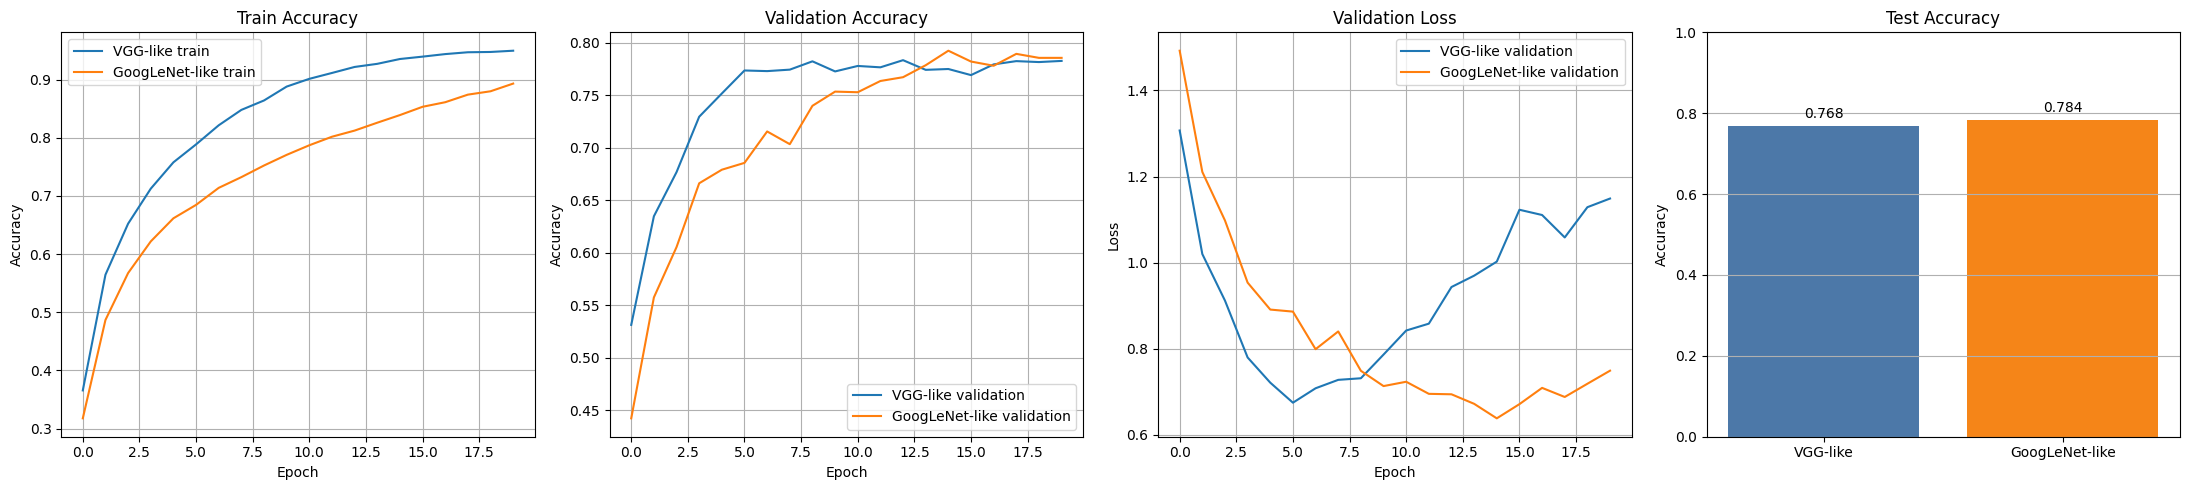

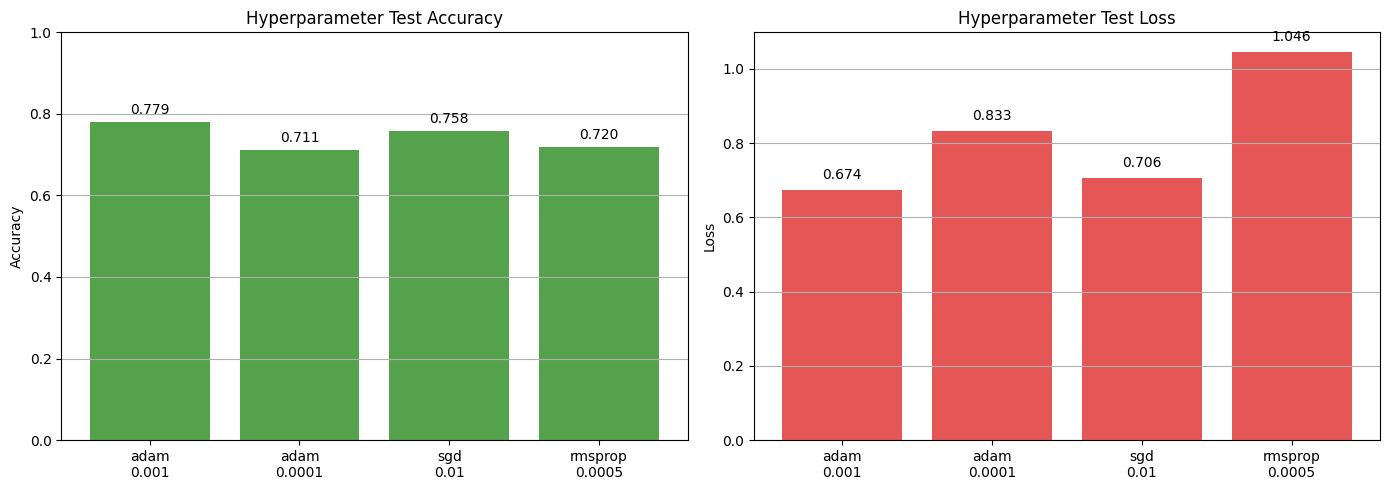

In [12]:
# Task: Visualize and compare the training history, test performance, and hyperparameter experiments
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for model_name, history in histories.items():
    axes[0].plot(history.history["accuracy"], label=f"{model_name} train")
    axes[1].plot(history.history["val_accuracy"], label=f"{model_name} validation")
    axes[2].plot(history.history["val_loss"], label=f"{model_name} validation")

axes[0].set_title("Train Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

axes[2].set_title("Validation Loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()
axes[2].grid(True)

model_names = [result["model"] for result in results]
test_accuracies = [result["test_accuracy"] for result in results]
axes[3].bar(model_names, test_accuracies, color=["#4C78A8", "#F58518"])
axes[3].set_title("Test Accuracy")
axes[3].set_ylabel("Accuracy")
axes[3].set_ylim(0, 1)
axes[3].grid(True, axis="y")
for index, value in enumerate(test_accuracies):
    axes[3].text(index, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

if "hyperparameter_results" in globals() and hyperparameter_results:
    labels = [f"{result['optimizer']}\n{result['learning_rate']}" for result in hyperparameter_results]
    hyper_test_accuracies = [result["test_accuracy"] for result in hyperparameter_results]
    hyper_test_losses = [result["test_loss"] for result in hyperparameter_results]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(labels, hyper_test_accuracies, color="#54A24B")
    axes[0].set_title("Hyperparameter Test Accuracy")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_ylim(0, 1)
    axes[0].grid(True, axis="y")
    for index, value in enumerate(hyper_test_accuracies):
        axes[0].text(index, value + 0.02, f"{value:.3f}", ha="center")

    axes[1].bar(labels, hyper_test_losses, color="#E45756")
    axes[1].set_title("Hyperparameter Test Loss")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True, axis="y")
    for index, value in enumerate(hyper_test_losses):
        axes[1].text(index, value + 0.03, f"{value:.3f}", ha="center")

    plt.tight_layout()
    plt.show()

## 4. Data Augmentation

Data augmentation can improve model generalization by increasing the diversity of the training data.

**Tasks:**
1. Apply common data augmentation techniques such as flipping, rotation, and brightness adjustments to the CIFAR-10 dataset.
2. Train the models with augmented data and compare the results to the original models.
3. Discuss the impact of data augmentation on training time and accuracy.

> **Answer:**
> 1. I applied horizontal flipping, small random rotation with factor 0.1, and random brightness adjustment with factor 0.1.
> 2. The augmented VGG-like model achieved test accuracy 0.7632 and test loss 0.6998, compared with the baseline VGG-like model's 0.7679 accuracy and 1.2138 loss. In this run, augmentation slightly reduced final test accuracy but clearly improved test loss.
> 3. Data augmentation increased training time from about 126.4 seconds to 196.6 seconds because each batch required extra preprocessing. It also reduced training accuracy, which suggests less memorization of the training set, and it kept validation loss lower for longer, indicating weaker overfitting even though the final test accuracy gain was not observed in this experiment.

In [ ]:
# Task: Train a model with data augmentation and compare it with the baseline
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomBrightness(0.1, value_range=(0, 1))
], name="data_augmentation")

def build_augmented_vgg_like(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    # Keras preprocessing layers apply random transforms during training only.
    x = data_augmentation(inputs)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="augmented_vgg_like")

augmented_model, augmented_history, augmented_result = train_and_evaluate(
    model_builder=build_augmented_vgg_like,
    model_name="Augmented VGG-like",
    learning_rate=1e-3,
    optimizer_name="adam",
    epochs=20,
    batch_size=64
)

baseline_vgg_result = next(result for result in results if result["model"] == "VGG-like")
baseline_vgg_history = histories["VGG-like"]

augmented_result

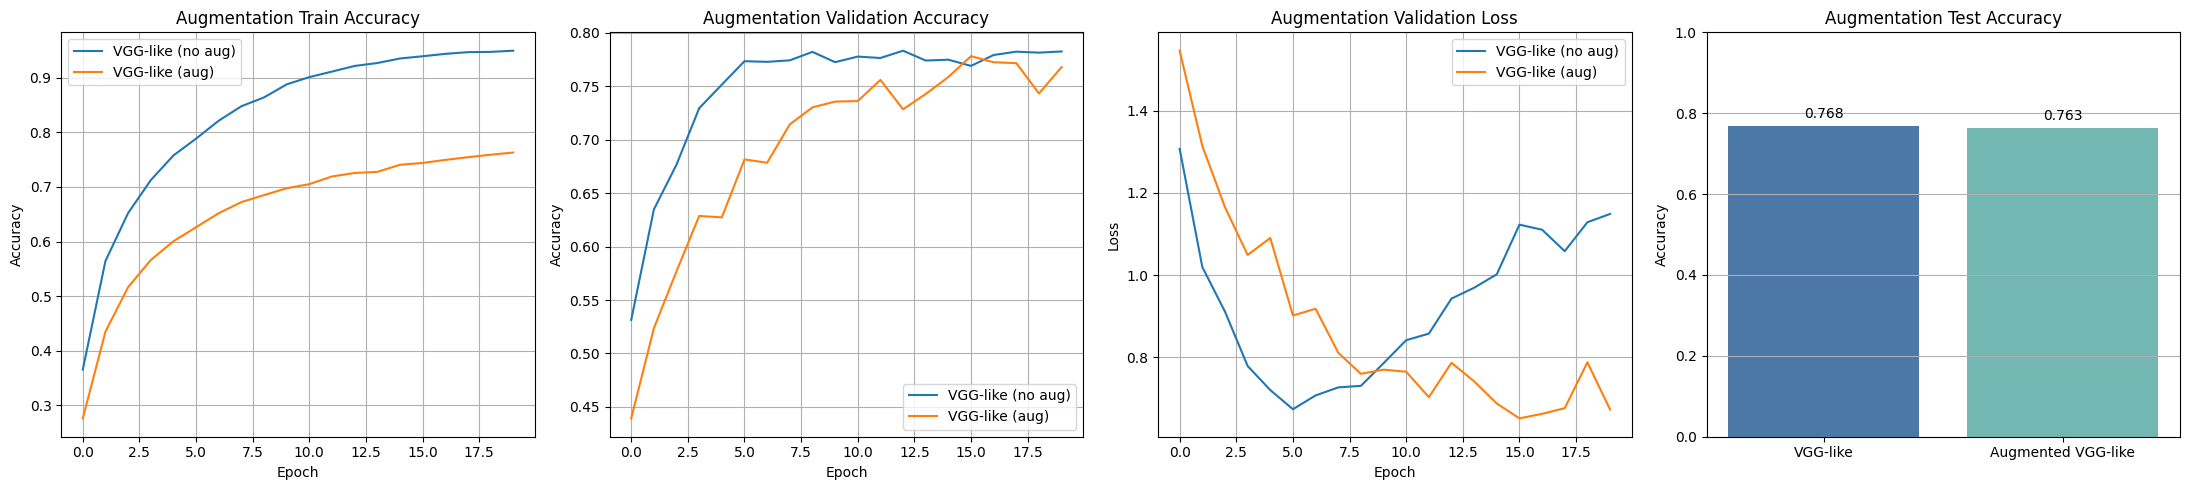

In [16]:
# Task: Compare the baseline and augmented VGG-like models
comparison_histories = {
    "VGG-like (no aug)": baseline_vgg_history,
    "VGG-like (aug)": augmented_history
}
comparison_results = [baseline_vgg_result, augmented_result]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for model_name, history in comparison_histories.items():
    axes[0].plot(history.history["accuracy"], label=model_name)
    axes[1].plot(history.history["val_accuracy"], label=model_name)
    axes[2].plot(history.history["val_loss"], label=model_name)

axes[0].set_title("Augmentation Train Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Augmentation Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

axes[2].set_title("Augmentation Validation Loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()
axes[2].grid(True)

comparison_names = [result["model"] for result in comparison_results]
comparison_test_accuracies = [result["test_accuracy"] for result in comparison_results]
axes[3].bar(comparison_names, comparison_test_accuracies, color=["#4C78A8", "#72B7B2"])
axes[3].set_title("Augmentation Test Accuracy")
axes[3].set_ylabel("Accuracy")
axes[3].set_ylim(0, 1)
axes[3].grid(True, axis="y")
for index, value in enumerate(comparison_test_accuracies):
    axes[3].text(index, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

## 5. Visualizing Feature Maps

Understanding how CNNs learn can be enhanced by visualizing the outputs of intermediate layers, also called feature maps.

**Tasks:**
1. Select a few test images and pass them through your trained models.
2. Visualize the feature maps at different layers of GoogLeNet and VGGNet.
3. Compare the patterns and features captured by earlier layers versus deeper layers.
4. Discuss how the visualized features contribute to classification.

> **Answer:**
> 1. I selected the first CIFAR-10 test image, using sample_index = 0. Its ground-truth label is cat.
> 2. I visualized the first three convolutional layers of the trained VGG-like model. The early feature maps highlight strong intensity changes near object boundaries, fur texture, and the contrast between the cat and the background. Some channels remain nearly inactive, showing that only certain filters respond strongly to this image.
> 3. Earlier layers capture low-level visual cues such as edges, contours, and texture fragments. Deeper layers become much sparser and more selective, preserving only the most informative regions, such as parts of the cat outline and high-contrast structures, while suppressing uniform background areas.
> 4. These visualized features support classification by progressively transforming raw pixels into more discriminative representations. Early layers detect reusable primitives, and deeper layers combine them into class-relevant patterns that help the network recognize the image as a cat rather than another animal or background scene.

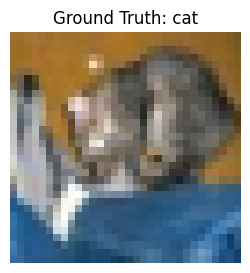

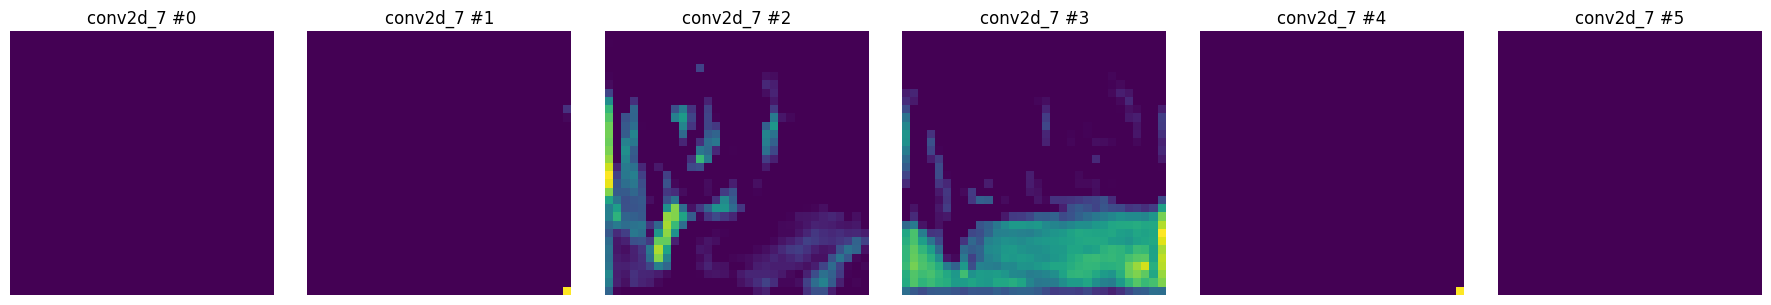

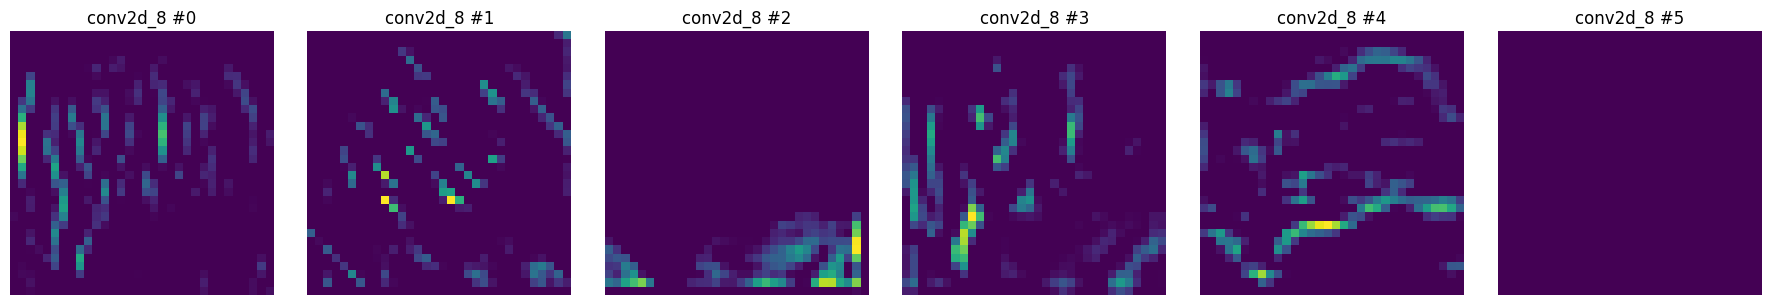

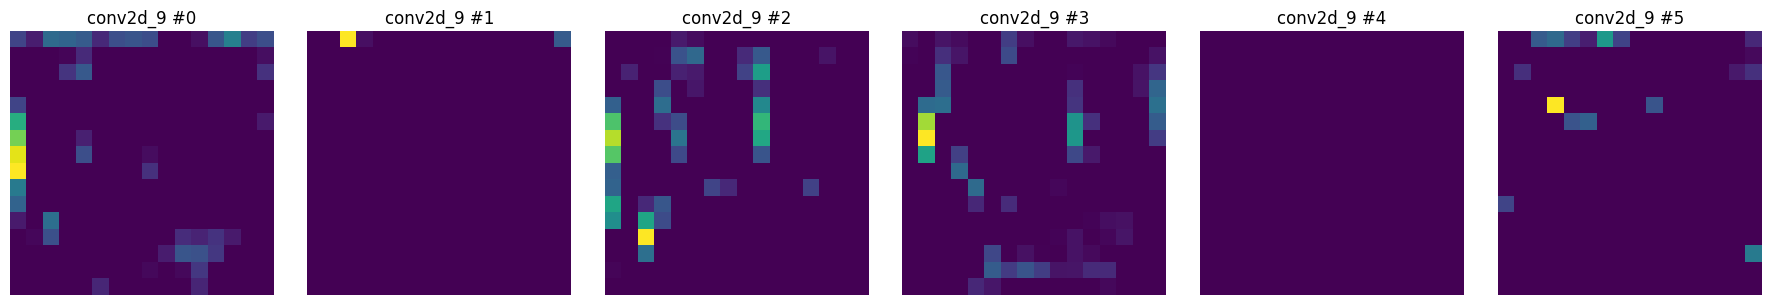

In [8]:
# Task: Visualize feature maps from intermediate convolution layers
def visualize_feature_maps(model, image_batch, layer_names, max_maps=6):
    feature_extractor = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(name).output for name in layer_names]
    )
    feature_maps = feature_extractor.predict(image_batch, verbose=0)

    for layer_name, fmap in zip(layer_names, feature_maps):
        num_maps = min(max_maps, fmap.shape[-1])
        fig, axes = plt.subplots(1, num_maps, figsize=(3 * num_maps, 3))
        if num_maps == 1:
            axes = [axes]
        for index in range(num_maps):
            axes[index].imshow(fmap[0, :, :, index], cmap="viridis")
            axes[index].axis("off")
            axes[index].set_title(f"{layer_name} #{index}")
        plt.tight_layout()
        plt.show()

sample_index = 0
sample_image = test_images[sample_index:sample_index + 1]

plt.figure(figsize=(3, 3))
plt.imshow(sample_image[0])
plt.title(f"Ground Truth: {class_names[test_labels[sample_index]]}")
plt.axis("off")
plt.show()

vgg_layer_names = [layer.name for layer in trained_models["VGG-like"].layers if isinstance(layer, layers.Conv2D)][:3]
visualize_feature_maps(trained_models["VGG-like"], sample_image, vgg_layer_names)

## 6. Reflection

**Questions to Reflect On:**
1. How do the performance metrics (accuracy and loss) of GoogLeNet and VGGNet compare?
2. What challenges did you face while implementing these architectures from scratch?
3. How does training from scratch differ from using pretrained models?
4. How did data augmentation influence the training and results?
5. What insights did you gain from visualizing feature maps?

> **Answer:**
> 1. GoogLeNet-like performed slightly better overall on the test set, reaching 0.7838 accuracy with 0.7471 loss, while VGG-like reached 0.7679 accuracy with 1.2138 loss. However, GoogLeNet-like also required more training time, about 192.8 seconds versus 126.4 seconds for VGG-like.
> 2. The main challenges were simplifying large classic architectures so they fit CIFAR-10, managing the parallel branches of the Inception design with the Functional API, and controlling overfitting while still keeping the models expressive enough to learn meaningful features.
> 3. Training from scratch requires learning all visual filters directly from the available dataset, so it usually needs more training time, more careful hyperparameter tuning, and more data. Pretrained models already contain useful generic visual features, so they usually converge faster and perform better when the dataset is limited.
> 4. Data augmentation increased training cost but reduced overfitting. In this notebook, the augmented VGG-like model trained more slowly and had slightly lower test accuracy, but it achieved a much lower test loss and showed more stable validation behavior.
> 5. The feature maps showed a clear progression from simple edges and texture detectors in early layers to sparse, class-relevant activations in deeper layers. This made it easier to see how the network filters out background noise and focuses on structures that matter for classification.


## Additional Resources

**Papers:**
- GoogLeNet: *Going Deeper with Convolutions*
- VGGNet: *Very Deep Convolutional Networks for Large-Scale Image Recognition*

**Suggested Follow-up:**
- Insert architecture diagrams or screenshots from the original papers.
- Compare your scratch implementations with transfer-learning baselines from pretrained models.